# 1. Download data

* Data come from kaggle: DataCo SMART SUPPLY CHAIN FOR BIG DATA ANALYSIS
https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis




In [ ]:
import kagglehub


path = kagglehub.dataset_download("shashwatwork/dataco-smart-supply-chain-for-big-data-analysis")

print("Path to dataset files:", path)

100%|██████████| 25.7M/25.7M [00:00<00:00, 137MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/versions/1


In [ ]:
import pandas as pd
import os

dataset_path = os.path.join(path, 'DataCoSupplyChainDataset.csv')
df = pd.read_csv(dataset_path, encoding='latin1')

In [ ]:
import os
os.listdir(path)

['tokenized_access_logs.csv',
 'DataCoSupplyChainDataset.csv',
 'DescriptionDataCoSupplyChain.csv']

# Phase 1: Data Inspection

In [ ]:
print(df.columns)
# what columns do I have?

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [ ]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrde

In [ ]:
display(df.head())

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
type( df.describe())

pandas.core.frame.DataFrame

In [ ]:
df.shape

(180519, 53)

In [ ]:
num_examples = df.shape[0]
print(f"The dataset has {num_examples} examples (rows).")

The dataset has 180519 examples (rows).


In [ ]:
df.info()
df.describe().transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


# Phase 2: The Cleanup


#### Remove missing values

In [ ]:
df.isnull().sum()
# checking empty values

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


After Using `df.isnull().sum()`, we can see the following columns have missing values:

- `Customer Lname`: 8 missing values (very few)
- `Customer Zipcode`: 3 missing values (very few)
- `Order Zipcode`: 155,679 missing values (most of the column is missing)
- `Product Description`: 180,519 missing values (all values are missing)

Here's how we'll handle them:
1.  *`Product Description`*: This column is entirely empty, so it provides no useful information. We will drop it.
2.  *`Order Zipcode`*: A large majority of this column is empty. We will drop it.
3.  *'Customer Lname` and `Customer Zipcode`*: These have a very small number of missing values. We will drop the rows that contain these few missing values, as it will have a minimal impact on the dataset size.

In [ ]:
df_cleaned = df.copy()

# Drop columns that are entirely or mostly empty
df_cleaned = df_cleaned.drop(columns=['Product Description', 'Order Zipcode'])

# Drop rows with a few missing values in 'Customer Lname' or 'Customer Zipcode'
df_cleaned = df_cleaned.dropna(subset=['Customer Lname', 'Customer Zipcode'])

print("Shape of DataFrame after cleaning missing values:", df_cleaned.shape)
display(df_cleaned.isnull().sum())

Shape of DataFrame after cleaning missing values: (180508, 51)


,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


 ### Remove not relevant for the current analysis

In [ ]:
irrelevant_columns = [
    'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password',
    'Customer Street', 'Customer Zipcode', 'Customer Id', 'Order Customer Id',
    'Product Image', 'Product Status', 'Product Card Id',
    'Product Category Id', 'Category Id', 'Department Id'
]

# Drop the irrelevant columns
df_cleaned = df_cleaned.drop(columns=irrelevant_columns)

print("Shape of DataFrame after dropping irrelevant columns:", df_cleaned.shape)
display(df_cleaned.head())

Shape of DataFrame after dropping irrelevant columns: (180508, 37)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,...,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,Smart watch,327.75,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,...,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,Smart watch,327.75,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,...,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,Smart watch,327.75,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,...,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,Smart watch,327.75,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,Smart watch,327.75,1/15/2018 11:24,Standard Class


In [ ]:
# Wir andern den Name von Type zu Type of payments
df.rename(columns={"Type":"Type Of Payments"},inplace=True)

Let's also convert the 'Order date (DateOrders)' and 'shipping date (DateOrders)' columns to datetime objects for easier time-series analysis.

In [ ]:
df_cleaned['order date (DateOrders)'] = pd.to_datetime(df_cleaned['order date (DateOrders)'])
df_cleaned['shipping date (DateOrders)'] = pd.to_datetime(df_cleaned['shipping date (DateOrders)'])

display(df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
Index: 180508 entries, 0 to 180518
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180508 non-null  object        
 1   Days for shipping (real)       180508 non-null  int64         
 2   Days for shipment (scheduled)  180508 non-null  int64         
 3   Benefit per order              180508 non-null  float64       
 4   Sales per customer             180508 non-null  float64       
 5   Delivery Status                180508 non-null  object        
 6   Late_delivery_risk             180508 non-null  int64         
 7   Category Name                  180508 non-null  object        
 8   Customer City                  180508 non-null  object        
 9   Customer Country               180508 non-null  object        
 10  Customer Segment               180508 non-null  object        
 11  Custo

None

### Zusatlich: Ubersetzung auf Deutsch
We will create a mapping dictionary for the most frequent categories and use the `.map()` function to create a new column `Category Name DE`.

In [ ]:
category_translation = {
    'Cleats': 'Stollenschuhe',
    "Men's Footwear": 'Herrenschuhe',
    "Women's Apparel": 'Damenbekleidung',
    'Indoor/Outdoor Games': 'Indoor/Outdoor Spiele',
    'Fishing': 'Angeln',
    'Water Sports': 'Wassersport',
    'Camping & Hiking': 'Camping & Wandern',
    'Cardio Equipment': 'Cardio-Geräte',
    'Shop By Sport': 'Nach Sportart',
    'Electronics': 'Elektronik',
    'Accessories': 'Zubehör',
    'Golf Balls': 'Golfbälle',
    "Girls' Apparel": 'Mädchenbekleidung',
    'Golf Gloves': 'Golfhandschuhe',
    'Trade-In': 'Inzahlungnahme',
    'Video Games': 'Videospiele'
}

# Create a new column with German translations
# .fillna() ensures that categories not in our dictionary keep their original English name
df_cleaned['Category Name DE'] = df_cleaned['Category Name'].map(category_translation).fillna(df_cleaned['Category Name'])

# Verify the translation
display(df_cleaned[['Category Name', 'Category Name DE']].drop_duplicates().head(10))

,Category Name,Category Name DE
0,Sporting Goods,Sporting Goods
48,Cleats,Stollenschuhe
49,Shop By Sport,Nach Sportart
50,Women's Apparel,Damenbekleidung
55,Electronics,Elektronik
56,Boxing & MMA,Boxing & MMA
59,Cardio Equipment,Cardio-Geräte
61,Trade-In,Inzahlungnahme
117,Kids' Golf Clubs,Kids' Golf Clubs
118,Hunting & Shooting,Hunting & Shooting


### Outlier Detection and Removal

We will now identify and remove outliers from several numerical columns using the Interquartile Range (IQR) method. The IQR method helps to define a range for data points, where values significantly above or below this range are considered outliers. Removing these extreme values can improve the robustness of subsequent analyses and models.

In [ ]:
# Identify numerical columns for outlier detection (excluding IDs, binary flags, and geographical coordinates)
numerical_cols_for_outliers = [
    'Benefit per order', 'Sales per customer', 'Order Item Discount',
    'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity',
    'Sales', 'Order Item Total', 'Order Profit Per Order',
    'Product Price', 'Days for shipping (real)', 'Days for shipment (scheduled)'
]

df_no_outliers = df_cleaned.copy()

# Loop through each selected numerical column to detect and remove outliers
for col in numerical_cols_for_outliers:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower_bound) & (df_no_outliers[col] <= upper_bound)]

print(f"Original DataFrame shape: {df_cleaned.shape}")
print(f"DataFrame shape after outlier removal: {df_no_outliers.shape}")

display(df_no_outliers.head())

Original DataFrame shape: (180508, 38)
DataFrame shape after outlier removal: (123360, 38)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,...,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode,Category Name DE
48,PAYMENT,5,2,-30.750000,115.180000,Late delivery,1,Cleats,Bayamon,Puerto Rico,...,115.180000,-30.750000,South Asia,Uttar Pradesh,PENDING_PAYMENT,Perfect Fitness Perfect Rip Deck,59.990002,2016-02-29 13:57:00,Second Class,Stollenschuhe
50,PAYMENT,6,2,33.599998,96.000000,Late delivery,1,Women's Apparel,Caguas,Puerto Rico,...,96.000000,33.599998,Oceania,Australia del Sur,PENDING_PAYMENT,Nike Men's Dri-FIT Victory Golf Polo,50.000000,2016-04-05 04:37:00,Second Class,Damenbekleidung
51,PAYMENT,2,2,24.690001,75.980003,Shipping on time,0,Shop By Sport,Caguas,Puerto Rico,...,75.980003,24.690001,West Asia,Estambul,PENDING_PAYMENT,Under Armour Girls' Toddler Spine Surge Runni,39.990002,2016-11-01 01:31:00,Second Class,Nach Sportart
52,PAYMENT,3,2,9.100000,91.000000,Late delivery,1,Women's Apparel,Caguas,Puerto Rico,...,91.000000,9.100000,Eastern Asia,Ulán Bator,PENDING_PAYMENT,Nike Men's Dri-FIT Victory Golf Polo,50.000000,2016-12-01 01:18:00,Second Class,Damenbekleidung
53,PAYMENT,5,2,-21.750000,87.000000,Late delivery,1,Women's Apparel,Caguas,Puerto Rico,...,87.000000,-21.750000,West Asia,Estambul,PENDING_PAYMENT,Nike Men's Dri-FIT Victory Golf Polo,50.000000,2017-01-05 15:47:00,Second Class,Damenbekleidung


In [ ]:
original_rows = df_cleaned.shape[0]
rows_after_outlier_removal = df_no_outliers.shape[0]

removed_rows = original_rows - rows_after_outlier_removal
percentage_removed = (removed_rows / original_rows) * 100

print(f"Number of original data points: {original_rows}")
print(f"Number of data points after outlier removal: {rows_after_outlier_removal}")
print(f"Number of data points removed as outliers: {removed_rows}")
print(f"Percentage of data points removed as outliers: {percentage_removed:.2f}%")

Number of original data points: 180508
Number of data points after outlier removal: 123360
Number of data points removed as outliers: 57148
Percentage of data points removed as outliers: 31.66%


In [ ]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [ ]:
df.drop_duplicates()

,Type Of Payments,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


Now that we have a numerical representation for 'Delivery Status', you can use 'Delivery_Status_Encoded' for further correlation analysis in the heatmap.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the features - Updated 'Type' to 'Type Of Payments' to match renamed column (neues Update)
features_to_check = ['Type Of Payments', 'Shipping Mode', 'Order Region', 'Category Name']

# 2. One-Hot Encoding creates a column for each category
X = pd.get_dummies(df[features_to_check])

# 3. Create our Target: We want to know what causes 'Late delivery' specifically
y = (df['Delivery Status'] == 'Late delivery').astype(int)

# Phase 3: Visual Exploration



  ### Product categories

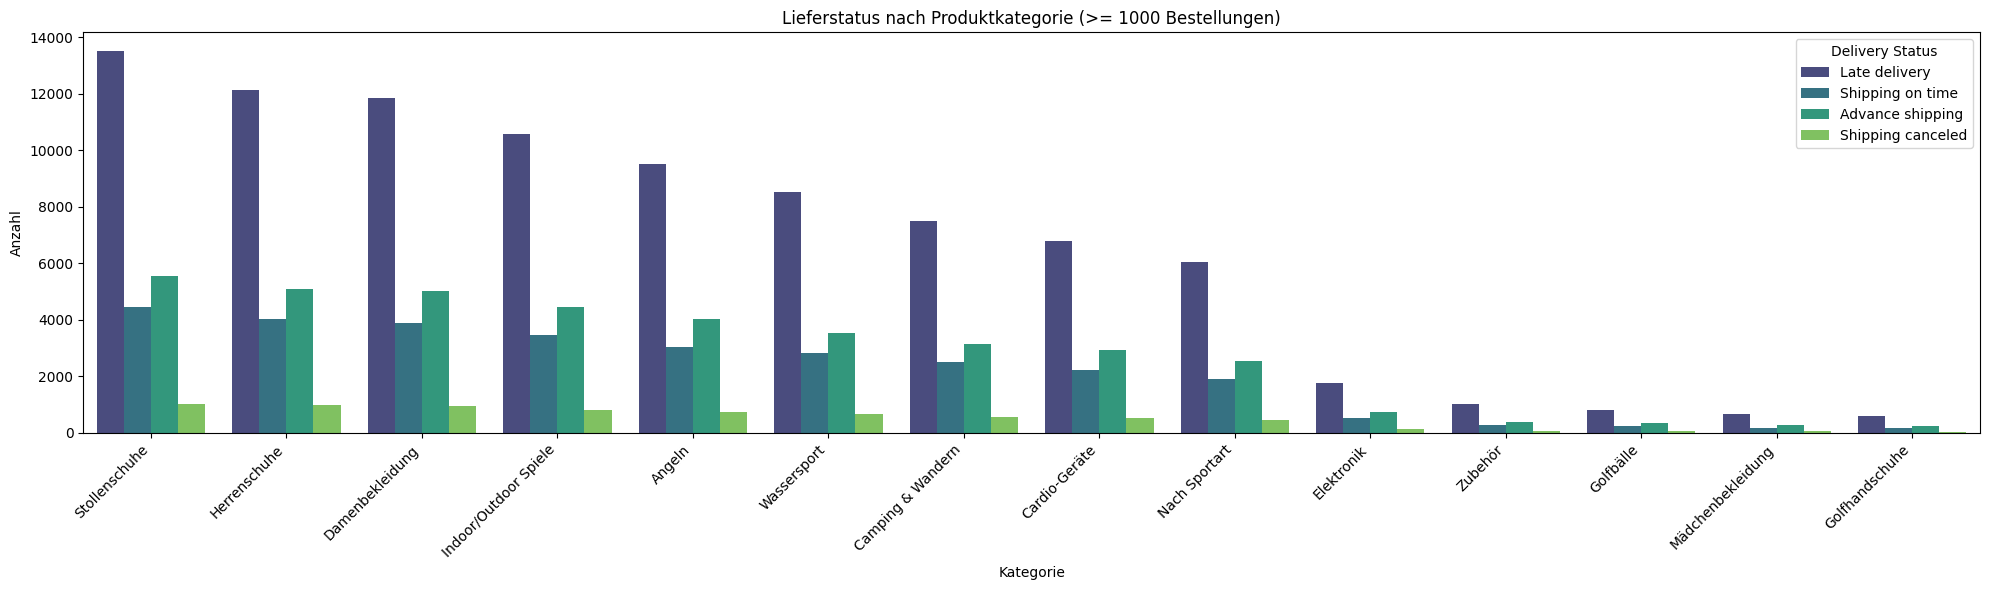

<Figure size 640x480 with 0 Axes>

In [ ]:
# Produkt Kategorien und Bestellmenge
plt.figure(figsize=(20, 6))

# 1. Identify categories with at least 1000 orders using the translated column
category_counts_de = df_cleaned['Category Name DE'].value_counts()
categories_to_plot = category_counts_de[category_counts_de >= 1000].index

# 2. Filter the cleaned dataframe
df_filtered_plot = df_cleaned[df_cleaned['Category Name DE'].isin(categories_to_plot)]

# 3. Create the plot
sns.countplot(data=df_filtered_plot, x='Category Name DE', hue='Delivery Status',
              palette='viridis', order=categories_to_plot)

plt.xticks(rotation=45, ha='right')
plt.title('Lieferstatus nach Produktkategorie (>= 1000 Bestellungen)')
plt.xlabel('Kategorie')
plt.ylabel('Anzahl')
plt.tight_layout()
plt.show()

# Fixed the call to use the existing 'plt' alias
plt.savefig('Lieferstatus_nach_Produktkategorie.png')

In [ ]:
# Calculate frequency and percentage of each Delivery Status
delivery_counts = df['Delivery Status'].value_counts().reset_index()
delivery_counts.columns = ['Delivery Status', 'Number of Orders']

# Calculate percentages
total_orders = delivery_counts['Number of Orders'].sum()
delivery_counts['Percentage'] = (delivery_counts['Number of Orders'] / total_orders * 100).round(2).astype(str) + '%'

print("Summary: Delivery Status distribution")
display(delivery_counts)

Summary: Delivery Status distribution


,Delivery Status,Number of Orders,Percentage
0,Late delivery,98977,54.83%
1,Advance shipping,41592,23.04%
2,Shipping on time,32196,17.84%
3,Shipping canceled,7754,4.3%


 ## Customers

/tmp/ipykernel_25930/1148661975.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Number of Orders', y='Order Region', data=region_counts, palette='viridis')


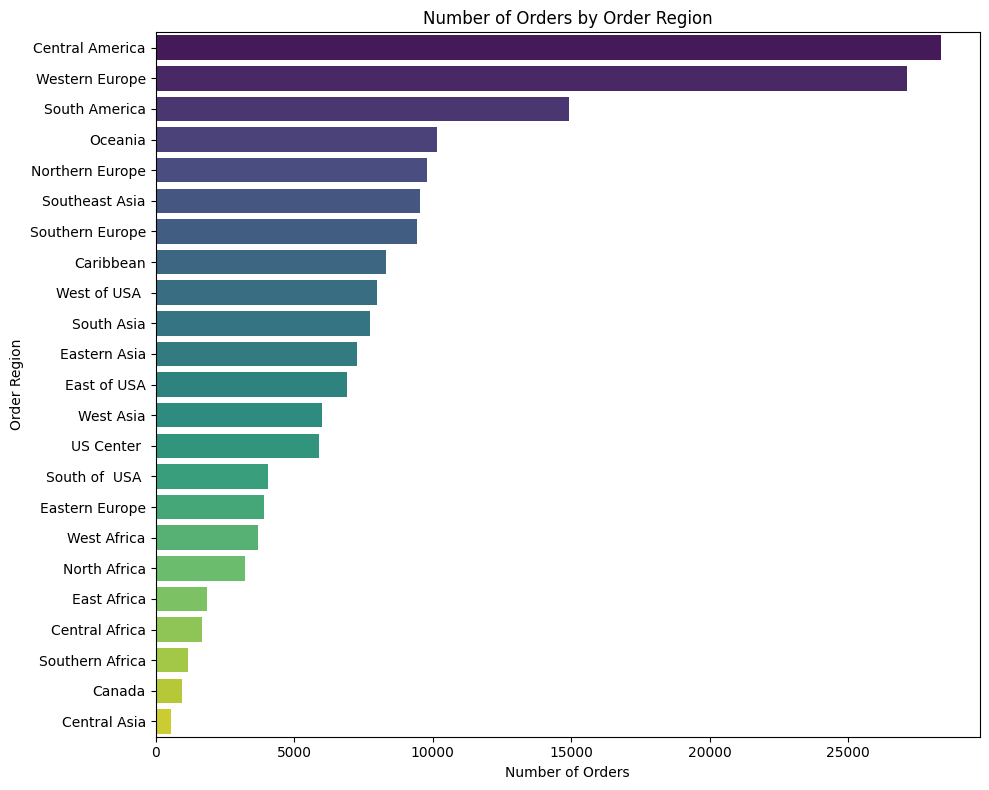

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the number of orders per Order Region and sort them
region_counts = df_cleaned['Order Region'].value_counts().reset_index()
region_counts.columns = ['Order Region', 'Number of Orders']

# 2. Create the horizontal bar plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Number of Orders', y='Order Region', data=region_counts, palette='viridis')

plt.title('Number of Orders by Order Region')
plt.xlabel('Number of Orders')
plt.ylabel('Order Region')
plt.tight_layout()
plt.show()

/tmp/ipykernel_25930/3655711572.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_cities.index, y=top_cities.values, palette='Oranges_d')


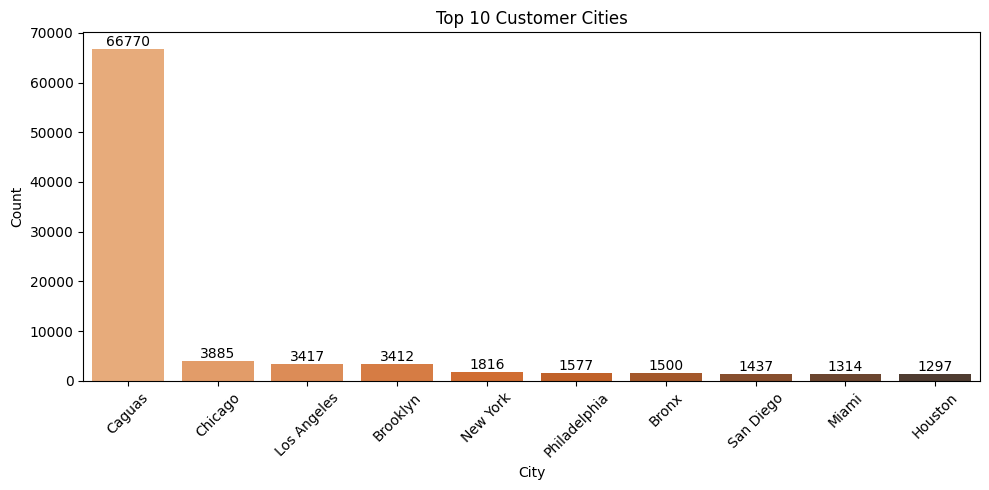

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# woher kommen die Kunden?
top_cities = df['Customer City'].value_counts().head(10)

plt.figure(figsize=(10,5))
ax = sns.barplot(x=top_cities.index, y=top_cities.values, palette='Oranges_d')
plt.title('Top 10 Customer Cities')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Add labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

  #### What types of customer do we have?

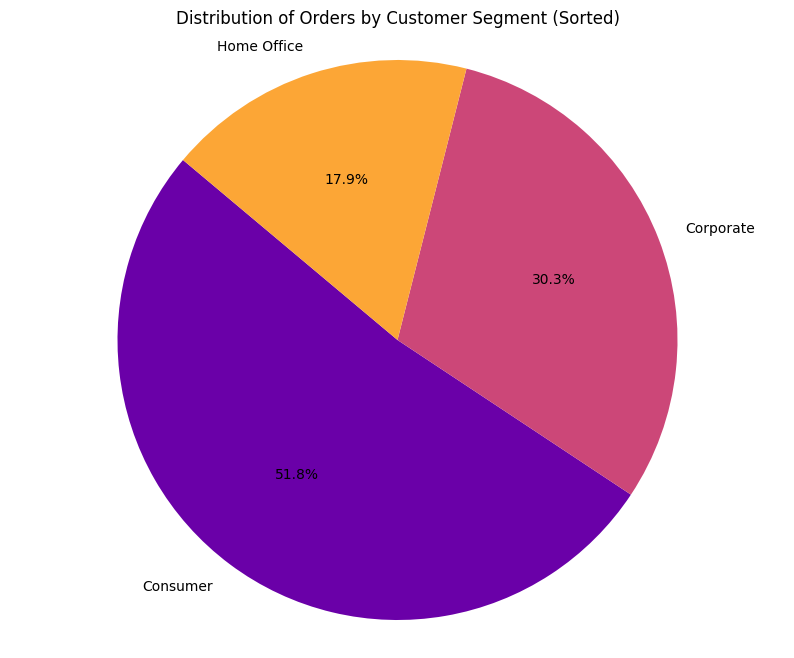

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# 1. Calculate counts and create a sorted DataFrame
segment_data = df_cleaned['Customer Segment'].value_counts().reset_index()
segment_data.columns = ['Customer Segment', 'Number of Orders']
segment_data = segment_data.sort_values(by='Number of Orders', ascending=False)

# 2. Create the pie chart
plt.figure(figsize=(10, 8))

# Use the plasma palette based on the number of segments
colors = cm.plasma(np.linspace(0.2, 0.8, len(segment_data)))

plt.pie(segment_data['Number of Orders'],
        labels=segment_data['Customer Segment'],
        autopct='%1.1f%%',
        startangle=140,
        colors=colors)

plt.title('Distribution of Orders by Customer Segment (Sorted)')
plt.axis('equal')

# Save the figure as a PNG file
plt.savefig('customer_segment_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

## Shipping Modes vs Delivery Status

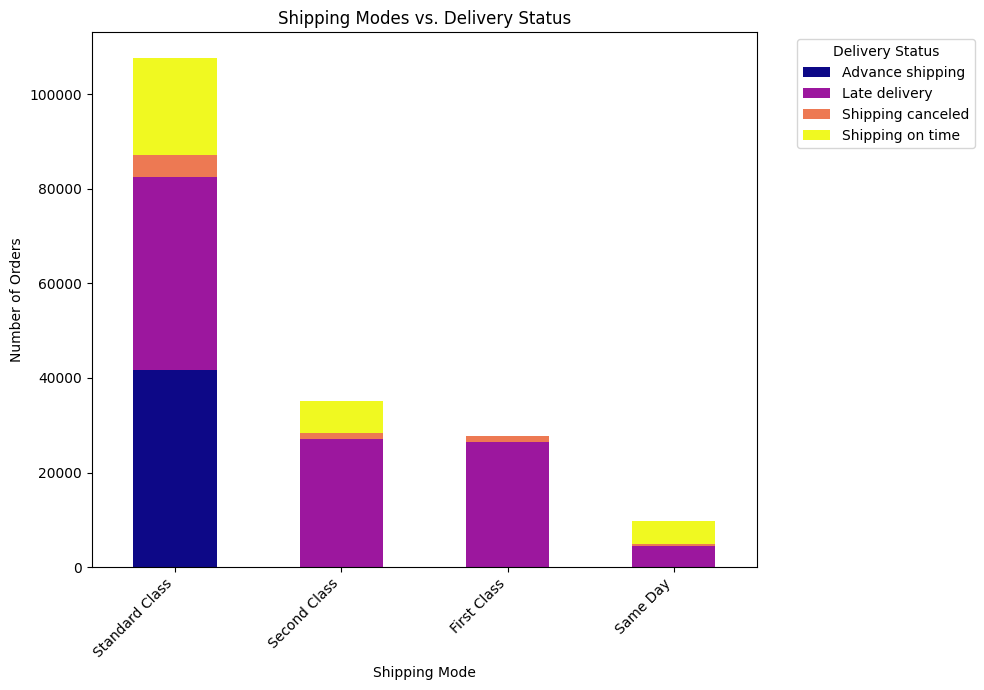

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create a stacked bar plot
shipping_status_ct = pd.crosstab(df['Shipping Mode'], df['Delivery Status'])

# 2. Sort by total number of orders - descending order
shipping_status_ct = shipping_status_ct.assign(Total=shipping_status_ct.sum(axis=1)).sort_values(by='Total', ascending=False).drop(columns='Total')

# 3. Create the stacked bar chart
ax = shipping_status_ct.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='plasma')



plt.title('Shipping Modes vs. Delivery Status')
plt.xlabel('Shipping Mode')
plt.ylabel('Number of Orders')
plt.legend(title='Delivery Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save
plt.savefig('Shipping_Modes_vs_Delivery_Status_Pct.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_25930/690307861.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Delivery Status', palette='plasma')


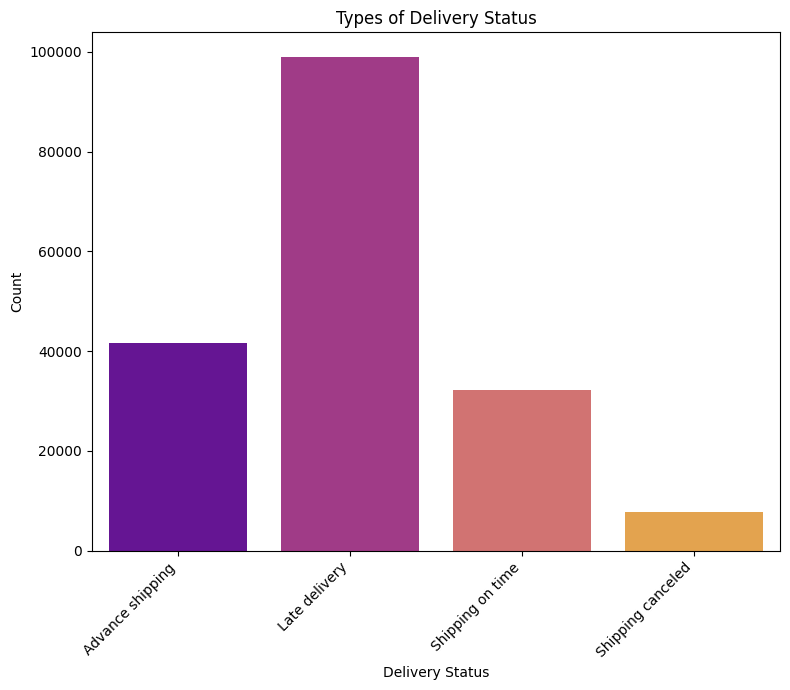

<Figure size 640x480 with 0 Axes>

In [ ]:
# What are the most frequent delivery statuses?
# result: Delivery status is mostly in "Late delivery"

plt.figure(figsize=(8,7))
sns.countplot(data=df, x='Delivery Status', palette='plasma')
plt.title('Types of Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# Save
plt.savefig('Types of Delivery Status.png', dpi=300, bbox_inches='tight')

## Product categories with the biggest delivery delays


In [1]:

# 10 top categories with Late Delivery
category_translation = {
    'Cleats': 'Stollenschuhe',
    "Men's Footwear": 'Herrenschuhe',
    "Women's Apparel": 'Damenbekleidung',
    'Indoor/Outdoor Games': 'Indoor/Outdoor Spiele',
    'Fishing': 'Angeln',
    'Water Sports': 'Wassersport',
    'Camping & Hiking': 'Camping & Wandern',
    'Cardio Equipment': 'Cardio-Geräte',
    'Shop By Sport': 'Nach Sportart',
    'Electronics': 'Elektronik',
    'Accessories': 'Zubehör',
    'Golf Balls': 'Golfbälle',
    "Girls' Apparel": 'Mädchenbekleidung',
    'Golf Gloves': 'Golfhandschuhe',
    'Trade-In': 'Inzahlungnahme',
    'Video Games': 'Videospiele'
}

late_deliveries_df = df[df['Delivery Status'] == 'Late delivery']

# Count late deliveries
late_counts = late_deliveries_df['Category Name'].value_counts()

# Fix: Create the new index by mapping, then using the original index values where mapping is missing
new_index = [category_translation.get(cat, cat) for cat in late_counts.index]
late_counts.index = new_index

print("Produktkategorien mit den meisten verspäteten Lieferungen:")
display(late_counts.head(10))

NameError: name 'df' is not defined

  ## Are the deliveries of products with high margin also delayed?

In [ ]:
# Welche Produktkategorien haben den hochsten Gweinn?
# 1. Define the updated translation dictionary
category_translation = {
    'Cleats': 'Stollenschuhe',
    "Men's Footwear": 'Herrenschuhe',
    "Women's Apparel": 'Damenbekleidung',
    'Indoor/Outdoor Games': 'Indoor/Outdoor Spiele',
    'Fishing': 'Angeln',
    'Water Sports': 'Wassersport',
    'Camping & Hiking': 'Camping & Wandern',
    'Cardio Equipment': 'Cardio-Geräte',
    'Shop By Sport': 'Nach Sportart',
    'Electronics': 'Elektronik',
    'Accessories': 'Zubehör',
    'Golf Balls': 'Golfbälle',
    "Girls' Apparel": 'Mädchenbekleidung',
    'Golf Gloves': 'Golfhandschuhe',
    'Trade-In': 'Inzahlungnahme',
    'Video Games': 'Videospiele',
    'Golf Bags & Carts':'Golftaschen & -wagen',
    'Toys': 'Spielzeuge',
    "Women's Clothing": 'Damenbekleidung',
    'Fitness Accessories': 'Fitnesszubehör',
    'Soccer': 'Fußball',
    "Men's Golf Clubs": 'Herrengolfschläger',
    "Women's Golf Clubs": 'Damengolfschläger',
    'Music': 'Musik',
    'Garden': 'Garten'
}

# 2. Re-apply the mapping to ensure all German names are updated in df_cleaned
df_cleaned['Category Name DE'] = df_cleaned['Category Name'].map(category_translation).fillna(df_cleaned['Category Name'])

# 3. Identify High Margin Categories using the refreshed German names
category_margins = df_cleaned.groupby('Category Name DE')['Order Item Profit Ratio'].mean().sort_values(ascending=False).reset_index()

print("Top 10 Kategorien nach durchschnittlicher Gewinnspanne:")
display(category_margins.head(10))
# Save the figure as a PNG file
plt.savefig('Top 10 Kategorien nach durchschnittlicher Gewinnspanne:.png', dpi=300, bbox_inches='tight')

Top 10 Kategorien nach durchschnittlicher Gewinnspanne:


,Category Name DE,Order Item Profit Ratio
0,Golftaschen & -wagen,0.191475
1,Spielzeuge,0.161928
2,Fitnesszubehör,0.151230
3,Fußball,0.146522
4,Herrengolfschläger,0.145618
5,Damengolfschläger,0.145580
6,Musik,0.142650
7,Garten,0.142521
8,Baby,0.139420
9,Baseball & Softball,0.137959


<Figure size 640x480 with 0 Axes>

### Analysis: High Margin Products vs. Delivery Performance
Are High margin Products delivered with prority or are they also delivered late?

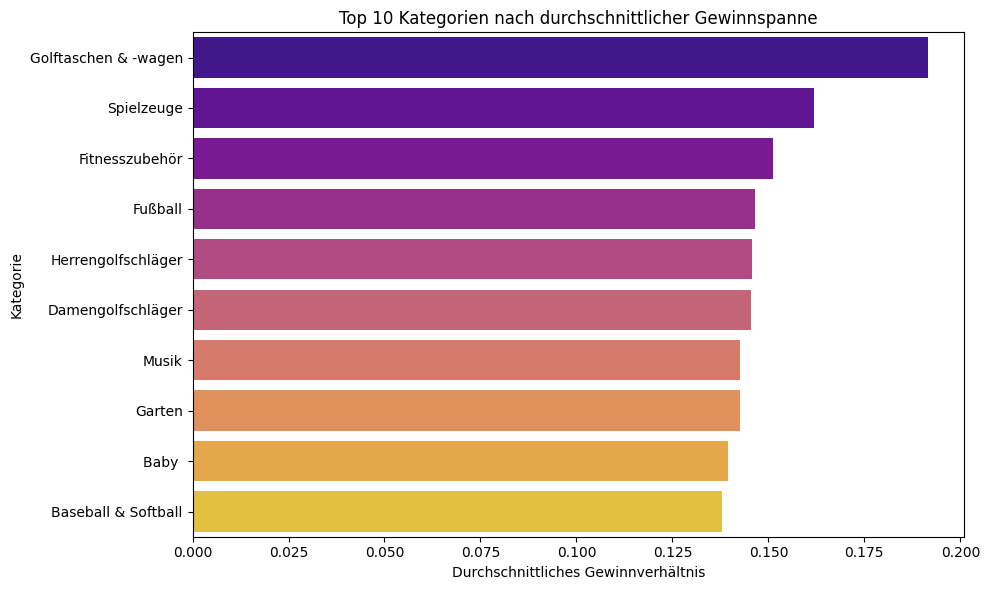

<Figure size 640x480 with 0 Axes>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate average profit margin per category using translated names
plot_data = category_margins.head(10)

# 2. Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='Order Item Profit Ratio', y='Category Name DE', palette='plasma', hue='Category Name DE', legend=False)

plt.title('Top 10 Kategorien nach durchschnittlicher Gewinnspanne')
plt.xlabel('Durchschnittliches Gewinnverhältnis')
plt.ylabel('Kategorie')
plt.tight_layout()
plt.show()
# Save the figure as a PNG file
plt.savefig('Top 10 Kategorien nach durchschnittlicher Gewinnspanne.png', dpi=300, bbox_inches='tight')

/tmp/ipykernel_25930/1090073142.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_25930/1090073142.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


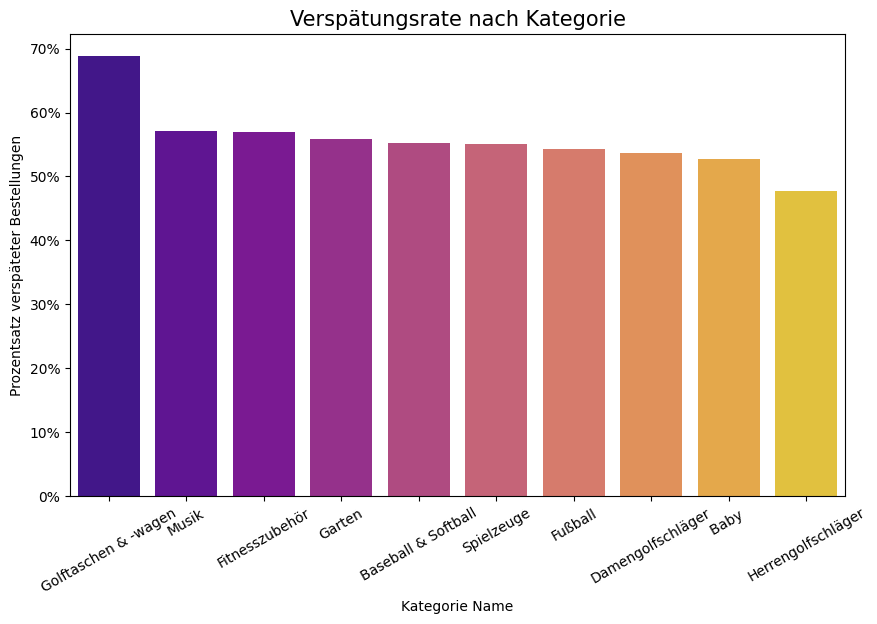

In [ ]:
# Wie viele Prozent von den Bestellungen mit dem Gewinnspannen haben Verspatungen?
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the binary column (1 for Late, 0 for Not Late)
df_cleaned['Is_Late'] = (df_cleaned['Delivery Status'] == 'Late delivery').astype(int)

# 2. Select your top 10 categories from the translated margin list
top_10_margin_cats = category_margins.head(10)['Category Name DE'].tolist()
df_high_margin = df_cleaned[df_cleaned['Category Name DE'].isin(top_10_margin_cats)]

# 3. CALCULATE THE SORT ORDER using translated names
sort_order = (df_high_margin.groupby('Category Name DE')['Is_Late']
              .mean()
              .sort_values(ascending=False)
              .index)

# 4. Simple Bar Plot with German labels
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_high_margin,
    x='Category Name DE',
    y='Is_Late',
    order=sort_order,
    palette='plasma',
    errorbar=None
)

# 5. Formatting
plt.title('Verspätungsrate nach Kategorie', fontsize=15)
plt.xlabel('Kategorie Name')
plt.ylabel('Prozentsatz verspäteter Bestellungen')

# Clean Y-axis labels (0.1 -> 10%)
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])

plt.xticks(rotation=30)
plt.show()

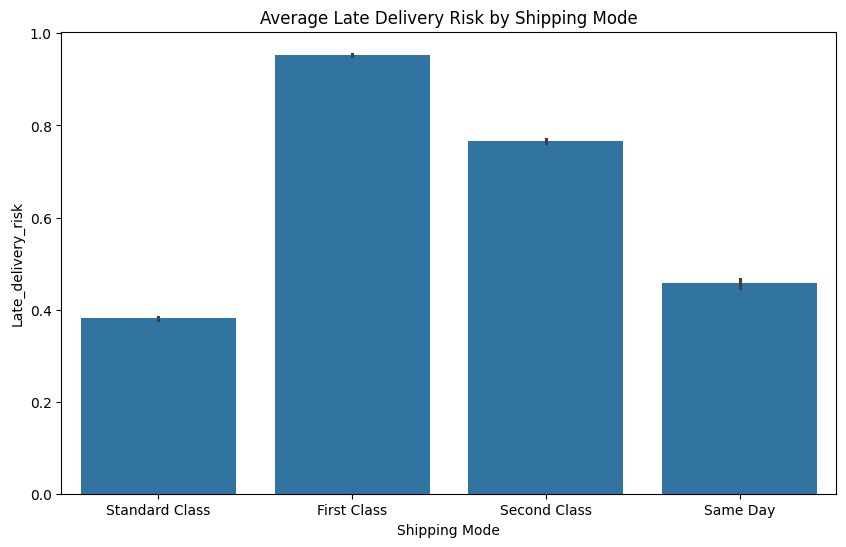

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
# This shows the average risk (0 to 1) for each shipping mode
sns.barplot(x='Shipping Mode', y='Late_delivery_risk', data=df)
plt.title('Average Late Delivery Risk by Shipping Mode')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Eine Vorbereitung fur unsere Heatmap (mit Late Delivery Risk)
# Create a copy to avoid SettingWithCopyWarning if necessary
df_corr_check = df_cleaned.copy()

# Encode Delivery Status: 0 for Advance, 1 for Late, 2 for Shipping on time, 3 for Canceled (order depends on alphabetical or manual)
le = LabelEncoder()
df_corr_check['Delivery_Status_Code'] = le.fit_transform(df_corr_check['Delivery Status'])

# Calculate correlation
correlation_value = df_corr_check[['Order Item Profit Ratio', 'Delivery_Status_Code']].corr()

print("Correlation Mapping for Delivery Status:")
for i, item in enumerate(le.classes_):
    print(f"{i}: {item}")

print("\nCorrelation Matrix:")
display(correlation_value)

Correlation Mapping for Delivery Status:
0: Advance shipping
1: Late delivery
2: Shipping canceled
3: Shipping on time

Correlation Matrix:


,Order Item Profit Ratio,Delivery_Status_Code
Order Item Profit Ratio,1.000000,0.001457
Delivery_Status_Code,0.001457,1.000000


  ### Shipping Mode vs Late delivery risk


 ### HEATMAP

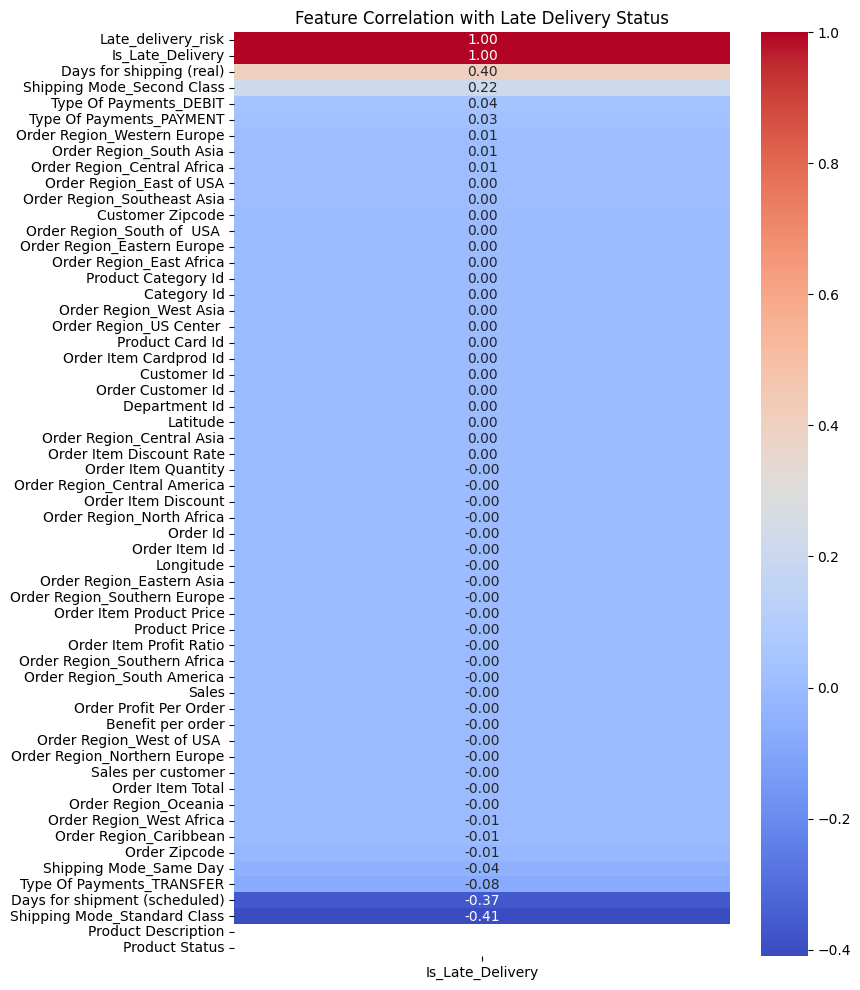

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. One-Hot Encode only the important categories first
# wir haben Type zu Type of Payment fruher gennant
X_encoded = pd.get_dummies(df[['Type Of Payments', 'Shipping Mode', 'Order Region']], drop_first=True)

# 2. Combine with existing numeric columns
# We ensure only numeric data is used for correlation
numeric_df = df.select_dtypes(include=[np.number])
df_for_heatmap = pd.concat([numeric_df, X_encoded], axis=1)

# 3. Add the target variable for correlation (Binary: 1 for Late, 0 for others)
df_for_heatmap['Is_Late_Delivery'] = (df['Delivery Status'] == 'Late delivery').astype(int)

# 4. Plot the heatmap
plt.figure(figsize=(8, 12))
correlation_with_target = df_for_heatmap.corr()[['Is_Late_Delivery']].sort_values(by='Is_Late_Delivery', ascending=False)

sns.heatmap(correlation_with_target, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Late Delivery Status')
plt.show()

# Phase 4:Predictions

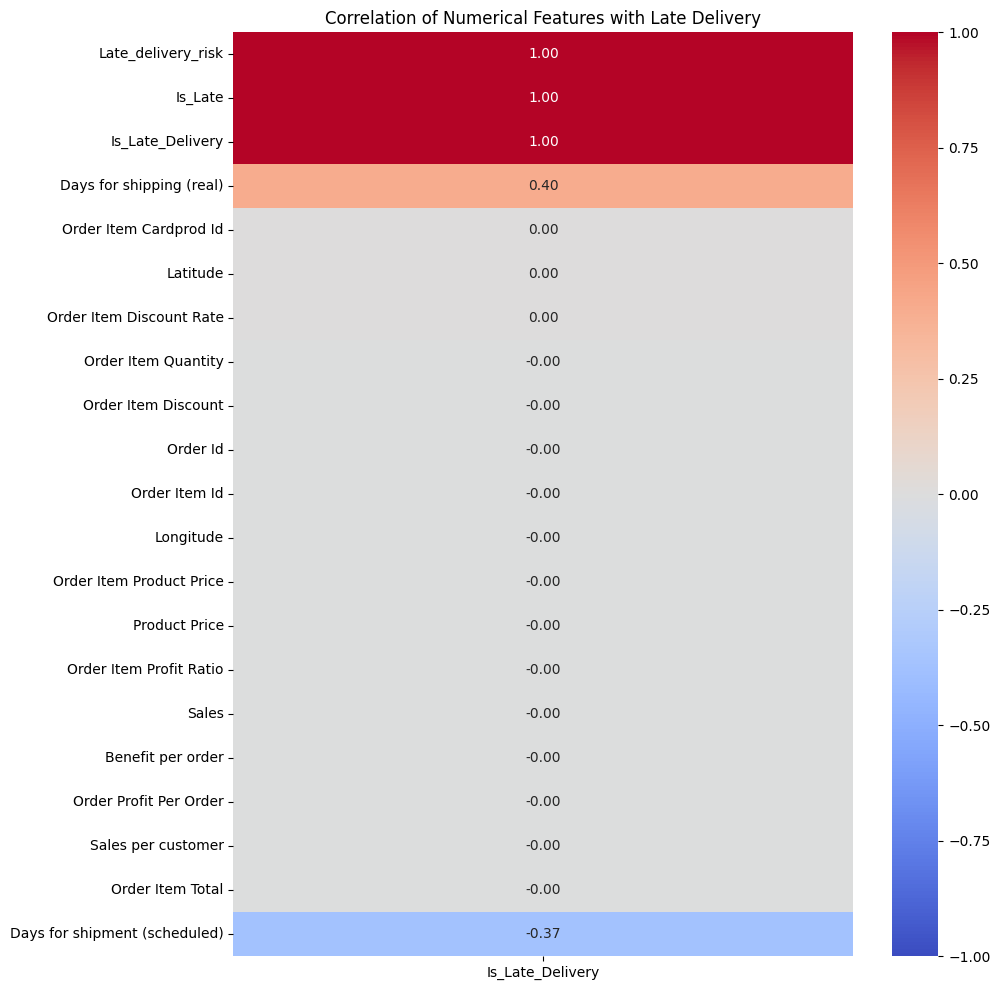

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data: Encode Delivery Status as binary (1 for Late delivery, 0 otherwise)
df_corr = df_cleaned.copy()
df_corr['Is_Late_Delivery'] = (df_corr['Delivery Status'] == 'Late delivery').astype(int)

# 2. Select numerical columns
numerical_cols = df_corr.select_dtypes(include=[np.number]).columns

# 3. Calculate Correlation Matrix
corr_matrix = df_corr[numerical_cols].corr()

# 4. Plot Heatmap focusing on 'Is_Late_Delivery'
plt.figure(figsize=(10, 12))
correlation_with_late = corr_matrix[['Is_Late_Delivery']].sort_values(by='Is_Late_Delivery', ascending=False)

sns.heatmap(correlation_with_late, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation of Numerical Features with Late Delivery')
plt.show()

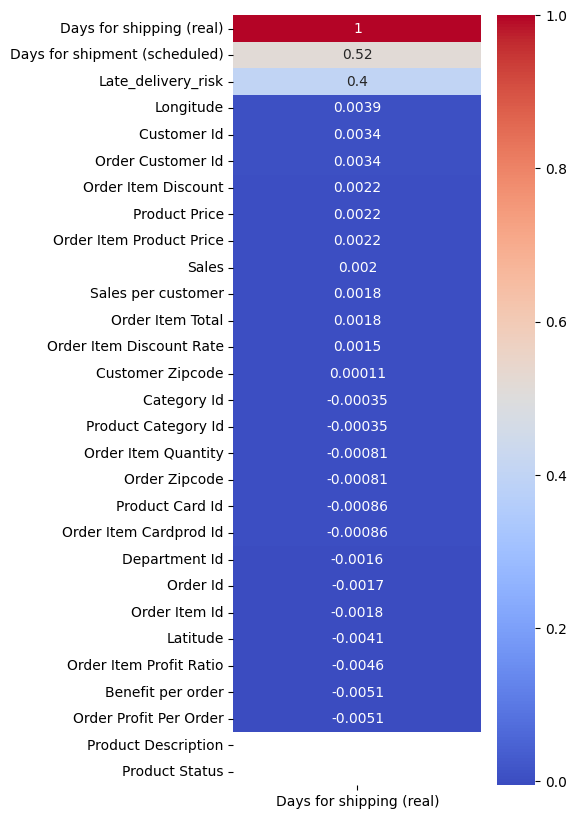

In [ ]:
# Create a correlation matrix to see relationships
import seaborn as sns
import matplotlib.pyplot as plt

# Use numeric_only=True to avoid errors with categorical data like 'DEBIT'
correlation_matrix = df.corr(numeric_only=True)

# Corrected the column name to 'Days for shipping (real)'
plt.figure(figsize=(4, 10))
sns.heatmap(correlation_matrix[['Days for shipping (real)']].sort_values(by='Days for shipping (real)', ascending=False), annot=True, cmap='coolwarm')
plt.show()

 ### RandomForestClassifier

### Validation: Which features actually correlate with Late Delivery?
Before assuming features are important, we can calculate the correlation coefficient. This helps us see which numerical values have a statistical link to delays.

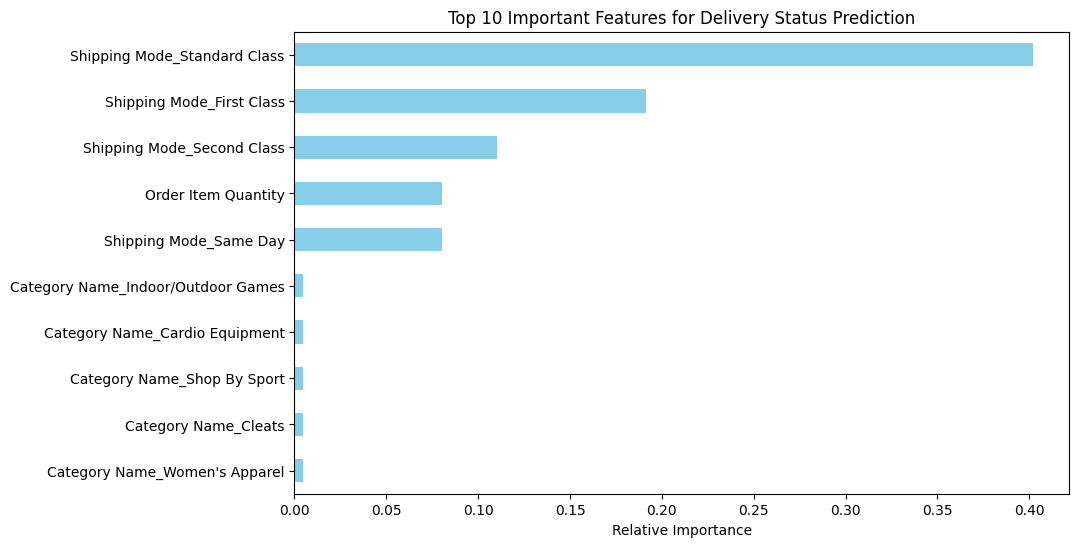

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define your Target (y) and your Features (X)
features = ['Shipping Mode', 'Order Region', 'Category Name', 'Order Item Quantity']
X = df[features]

# We need to encode the Target (y) because it contains strings
le = LabelEncoder()
y = le.fit_transform(df['Delivery Status'])

# 2. Convert text features to numbers (One-Hot Encoding)
X = pd.get_dummies(X)

# 3. Fit the model - Changed to Classifier for categorical data
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X, y)

# 4. Get the scores
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh', color='skyblue')
plt.title("Top 10 Important Features for Delivery Status Prediction")
plt.xlabel("Relative Importance")
plt.show()

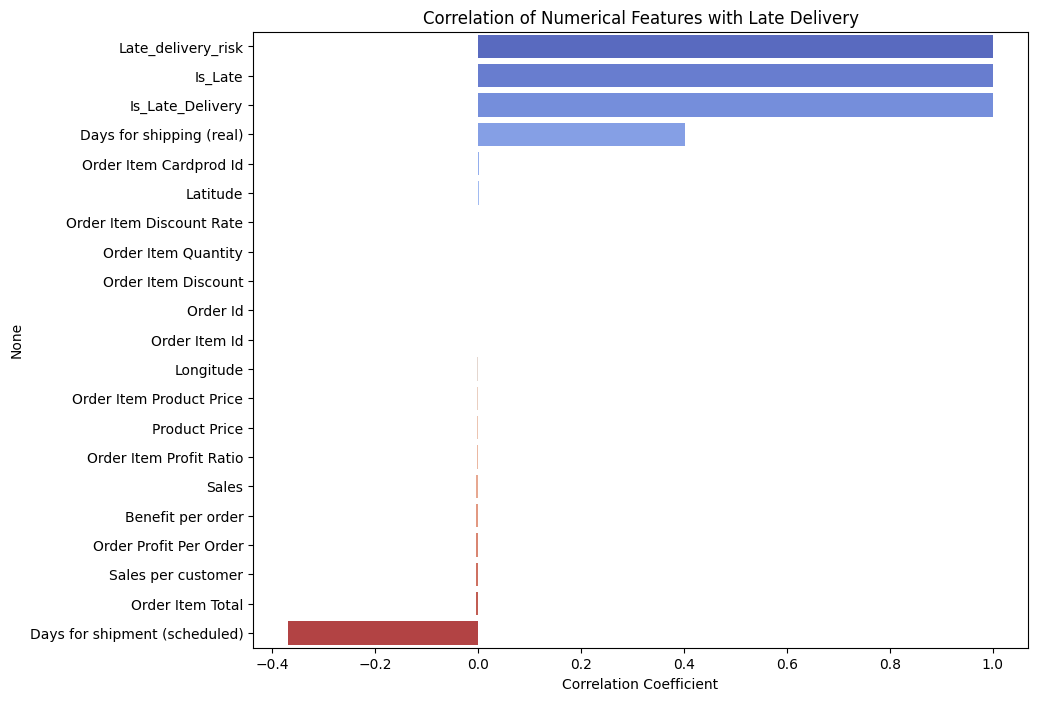

Top Correlation values:


,Is_Late_Delivery
Late_delivery_risk,1.000000
Is_Late,1.000000
Is_Late_Delivery,1.000000
Days for shipping (real),0.401418
Order Item Cardprod Id,0.001513
Latitude,0.000700
Order Item Discount Rate,0.000399
Order Item Quantity,-0.000148
Order Item Discount,-0.000739
Order Id,-0.001273


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a binary target for 'Late delivery'
df_cleaned['Is_Late_Delivery'] = (df_cleaned['Delivery Status'] == 'Late delivery').astype(int)

# 2. Select numerical columns to check
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns

# 3. Calculate correlation with the target
correlations = df_cleaned[numeric_cols].corr()['Is_Late_Delivery'].sort_values(ascending=False)

# 4. Visualize the top correlations
plt.figure(figsize=(10, 8))
# Fixed warning by assigning 'hue' to the y variable
sns.barplot(x=correlations.values, y=correlations.index, hue=correlations.index, palette='coolwarm', legend=False)
plt.title('Correlation of Numerical Features with Late Delivery')
plt.xlabel('Correlation Coefficient')
plt.show()

print("Top Correlation values:")
display(correlations.head(10))

### Classification: Simple Probability Prediction: Logistic Regression
We will use Logistic Regression to calculate the mathematical 'chance' (probability) of a delay for future orders.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# 1. Prepare Features (X) and Target (y)
X = pd.get_dummies(df_cleaned[['Shipping Mode', 'Days for shipment (scheduled)']], drop_first=True)
y = (df_cleaned['Delivery Status'] == 'Late delivery').astype(int)

# 2. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the model ONLY on the training set
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

# 4. Evaluate: How good is the model actually?
predictions = model_lr.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy on unseen data: {accuracy:.2%}")

# 5. Predict for the 'Next 50'
# (Using the average probability from the test set as a proxy for future orders)
probabilities = model_lr.predict_proba(X_test)[:, 1]
avg_chance = np.mean(probabilities)
print(f"Average chance of delay: {avg_chance:.2%}")
print(f"In the next 50 orders, we expect ~{round(50 * avg_chance)} delays.")

Model Accuracy on unseen data: 69.78%
Average chance of delay: 54.89%
In the next 50 orders, we expect ~27 delays.


In [ ]:
# Get the names of the features from get_dummies
feature_names = X.columns
# Get the importance (coefficients)
importances = model_lr.coef_[0]

# Create a small dataframe for plotting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

                         Feature  Importance
0  Days for shipment (scheduled)   -0.469074
2     Shipping Mode_Second Class   -1.353670
3   Shipping Mode_Standard Class   -2.083370
1         Shipping Mode_Same Day   -3.661055


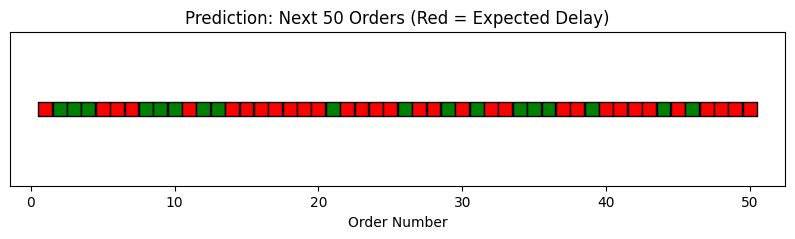

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Simulate 50 orders based on your model's avg_chance
np.random.seed(42) # Keeps the "random" dots the same every time you run it
next_50 = np.random.choice(['Late', 'On-Time'], size=50, p=[0.5489, 1-0.5489])

# Plotting the "Future"
plt.figure(figsize=(10, 2))
colors = ['red' if status == 'Late' else 'green' for status in next_50]
plt.scatter(range(1, 51), [1]*50, c=colors, s=100, marker='s', edgecolors='black')

plt.title("Prediction: Next 50 Orders (Red = Expected Delay)")
plt.xlabel("Order Number")
plt.yticks([]) # Hide the Y-axis
plt.show()

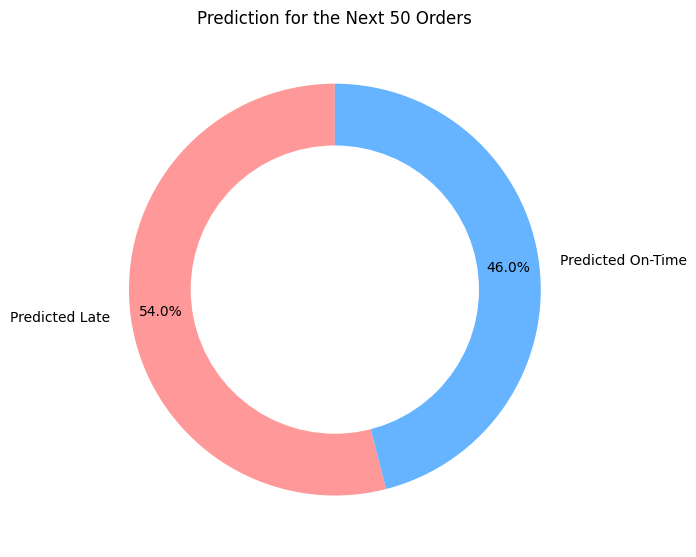

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# Data from my prediction
late_count = 27
ontime_count = 50 - late_count

# Plotting
plt.figure(figsize=(7, 7))
plt.pie([late_count, ontime_count], labels=['Predicted Late', 'Predicted On-Time'],
        colors=['#ff9999','#66b3ff'], autopct='%1.1f%%', startangle=90, pctdistance=0.85)

# Draw a circle at the center to make it a donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Prediction for the Next 50 Orders")
plt.tight_layout()
plt.show()
plt.savefig("Prediction for the Next 50 Orders.png", dpi=300, bbox_inches='tight')

In [ ]:
# Create 50 "fake" First Class orders (wir vermuten, das die Transit Zeit ist 2 Tage)
fake_first_class = pd.DataFrame({
    'Days for shipment (scheduled)': [2]*50,
    'Shipping Mode_Same Day': [0]*50,
    'Shipping Mode_Second Class': [0]*50,
    'Shipping Mode_Standard Class': [0]*50
})

# Predict for this specific scenario - Lieferung nur mit First Class Shipping Mode
risk = model_lr.predict_proba(fake_first_class)[:, 1].mean()
print(f"Risk if all 50 are First Class: {risk:.2%}")

Risk if all 50 are First Class: 92.70%


In [ ]:
# jetzt nur mit Standard Class (wir vermuten dass die Transit Zeit is 6 Tage)
# Create 50 "fake" Standard Class orders
fake_standard_class = pd.DataFrame({
    'Days for shipment (scheduled)': [6]*50,
    'Shipping Mode_Same Day': [0]*50,
    'Shipping Mode_Second Class': [0]*50,
    'Shipping Mode_Standard Class': [1]*50
})

# Predict for this specific scenario
risk_standard = model_lr.predict_proba(fake_standard_class)[:, 1].mean()
print(f"Risk if all 50 are Standard Class: {risk_standard:.2%}")

Risk if all 50 are Standard Class: 19.49%
